<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2_SERS_Semestre_2/blob/main/CP2_SERS_Semestre_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CP2 | SERS | 2° Semestre**

*INTEGRANTE*

Nome: Pedro Henrique Neves<br>
RM:   571382

*BIBILIOTECAS*

In [33]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

*PROJETO*

In [9]:
# 1. Fonte de Dados

# Informações do projeto
cidade = "São Paulo (SP)"
lat = -23.55
lon = -46.63
start_year = 2020
end_year = 2020

# Parâmetros para API
peakpower = 1.0
loss = 14.0

# URL do PVGIS
url = f"https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat={lat}&lon={lon}&peakpower={peakpower}&loss={loss}&outputformat=csv&startyear={start_year}&endyear={end_year}&pvcalculation=1"

print("=== REGISTRO DA ATIVIDADE ===")
print(f"Cidade: {cidade}")
print(f"Latitude: {lat}")
print(f"Longitude: {lon}")
print(f"Período consultado: De {start_year} até {end_year}")
print(f"Endereço (URL) utilizado:\n{url}\n")

=== REGISTRO DA ATIVIDADE ===
Cidade: São Paulo (SP)
Latitude: -23.55
Longitude: -46.63
Período consultado: De 2020 até 2020
Endereço (URL) utilizado:
https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.55&lon=-46.63&peakpower=1.0&loss=14.0&outputformat=csv&startyear=2020&endyear=2020&pvcalculation=1



In [19]:
# 2. Obtenção e Organização dos Dados

print("=== BAIXANDO E LENDO OS DADOS DA API ===")

# 3. Obtendo .csv do PVGIS
response = requests.get(url)
response.raise_for_status()

# Organizando o .csv com os metadados
linhas = response.text.splitlines()
linha_inicio = 0

for i, linha in enumerate(linhas):
    if 'time' in linha.lower() or 'date' in linha.lower():
        linha_inicio = i
        break

# Trazendo o database como variável python
csv_data = "\n".join(linhas[linha_inicio:])
df = pd.read_csv(io.StringIO(csv_data), on_bad_lines='skip')

# Exibindo as primeiras 5 linhas do db
display(df.head())

=== BAIXANDO E LENDO OS DADOS DA API ===


,time,P,G(i),H_sun,T2m,WS10m,Int
0,20200101:0003,0.0,0.0,0.0,22.79,1.72,0.0
1,20200101:0103,0.0,0.0,0.0,22.32,1.72,0.0
2,20200101:0203,0.0,0.0,0.0,21.90,1.59,0.0
3,20200101:0303,0.0,0.0,0.0,21.47,1.52,0.0
4,20200101:0403,0.0,0.0,0.0,21.18,1.52,0.0


In [31]:
# 3. Inspeção Inicial do DataFrame
print('INSPEÇÂO INICIAL DO DATAFRAME')
print(f'\n{'=~' * 30}\n')

# Exibindo quantidade de linhas e colunas da tabela
linhas, colunas = df.shape

print(f'Quantidade de linhas: {linhas}')
print(f'Quantidade de colunas: {colunas}')

print(f'\n{'=~' * 30}\n')

# Identificando e mudando os nomes dos tópicos
print("Nomes exatos das colunas no CSV:", list(df.columns))

# Renoameando nomes das colunas
df = df.rename(columns={
    'time': 'Data_Hora',
    'P': 'Potencia_Fotovoltaica',
    'G(i)': 'Irradiancia_Solar',
    'T2m': 'Temperatura',
    'WS10m': 'Velocidade_Vento',
    'H_sun': 'Altura_Solar'
})

# Exibindo nomes renomeados das colunas
print(f'\n{'=~' * 30}\n')
print("Nomes renomeados das colunas no CSV:", list(df.columns))

# Exibindo tipos de dados das colunas
print(f'\n{'=~' * 30}\n')
print('Tipos de dados das colunas do DataFrame:')
print(df.dtypes)

# Exibindo quantidade de valores ausentes
print(f'\n{'=~' * 30}\n')
print('Valores Ausentes?:')
print(df.isnull().sum())

# Exibindo estatísticas principais de variáveis num
print(f'\n{'=~' * 30}\n')
print('Estatísticas Principais das Variáveis Numéricas:')
print(df.describe())

# Exibindo registros em geração ou irradiança
print(f'\n{'=~' * 30}\n')
print('Registros que apresentam periódos sem geração ou sem irradiança?:')

sem_geracao = (df['Potencia_Fotovoltaica'] == 0).sum()
sem_irradiancia = (df['Irradiancia_Solar'] == 0).sum()
ambos_zero = ((df['Potencia_Fotovoltaica'] == 0) & (df['Irradiancia_Solar'] == 0)).sum()

print(f'- Registros sem geração (Potencia_Fotovoltaica = 0): {sem_geracao}')
print(f'- Registros sem irradiança (Irradiancia_Solar = 0): {sem_irradiancia}')
print(f'- Registros com ambos zero (geralmente período noturno): {ambos_zero}')
print(f'\n{'=~' * 30}')

INSPEÇÂO INICIAL DO DATAFRAME

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Quantidade de linhas: 8791
Quantidade de colunas: 7

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Nomes exatos das colunas no CSV: ['Data_Hora', 'Potencia_Fotovoltaica', 'Irradiancia_Solar', 'Altura_Solar', 'Temperatura', 'Velocidade_Vento', 'Int']

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Nomes renomeados das colunas no CSV: ['Data_Hora', 'Potencia_Fotovoltaica', 'Irradiancia_Solar', 'Altura_Solar', 'Temperatura', 'Velocidade_Vento', 'Int']

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Tipos de dados das colunas do DataFrame:
Data_Hora                 object
Potencia_Fotovoltaica     object
Irradiancia_Solar        float64
Altura_Solar             float64
Temperatura              float64
Velocidade_Vento         float64
Int                      float64
dtype: object

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Valores Aus

Optou-se por manter os registros noturnos (períodos em que a irradiação $Irradiancia Solar = 0$ e a potência $PotenciaFotovoltaica = 0$) no conjunto de dados.<br>Justificativa: Os dados noturnos representam o comportamento físico real de uma usina fotovoltaica ao longo do ciclo diário de 24 horas. Excluir esses dados poderia introduzir um viés no modelo, fazendo com que ele ignore os momentos de inatividade e prejudique previsões contínuas de longo prazo. Além disso, a manutenção preserva a integridade cronológica da série temporal horária.

In [32]:
# 4. Definição do Problema de Regressão

# Definindo valor y
y = df['Potencia_Fotovoltaica']

# Definindo valor x
features = ['Irradiancia_Solar', 'Temperatura', 'Velocidade_Vento', 'Altura_Solar']
X = df[features]

# Exibindo as primeiras linhas para conferência
print("Variável Alvo (y - Primeiros valores):")
display(y.head())

print("\nVariáveis Preditoras (X - Primeiras linhas):")
display(X.head())

Variável Alvo (y - Primeiros valores):


,Potencia_Fotovoltaica
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0



Variáveis Preditoras (X - Primeiras linhas):


,Irradiancia_Solar,Temperatura,Velocidade_Vento,Altura_Solar
0,0.0,22.79,1.72,0.0
1,0.0,22.32,1.72,0.0
2,0.0,21.90,1.59,0.0
3,0.0,21.47,1.52,0.0
4,0.0,21.18,1.52,0.0


Definição e Justificativa do Problema de Regressão:Variável Alvo ($y$): Potencia_Fotovoltaica Justificativa: É a métrica principal que o modelo de regressão tentará prever, representando a energia elétrica útil entregue pelo sistema em cada hora.Variáveis Preditoras ($X$): Irradiancia_Solar: É o fator físico mais determinante para a geração solar. Quanto maior a incidência de radiação sobre os painéis, maior tende a ser a potência gerada.H_sun (Altura do Sol / Elevação Solar): Define a posição geométrica do Sol no céu ao longo do dia, ditando diretamente a disponibilidade de luz e os ângulos de incidência que afetam a eficiência da captação.Temperatura : A temperatura ambiente afeta a eficiência térmica das células fotovoltaicas (geralmente, quanto mais quentes ficam as placas além da condição padrão, menor é a sua eficiência de conversão).Velocidade_Vento: O vento desempenha um papel importante na refrigeração natural dos módulos fotovoltaicos, ajudando a mitigar perdas de eficiência causadas pelo aquecimento excessivo.

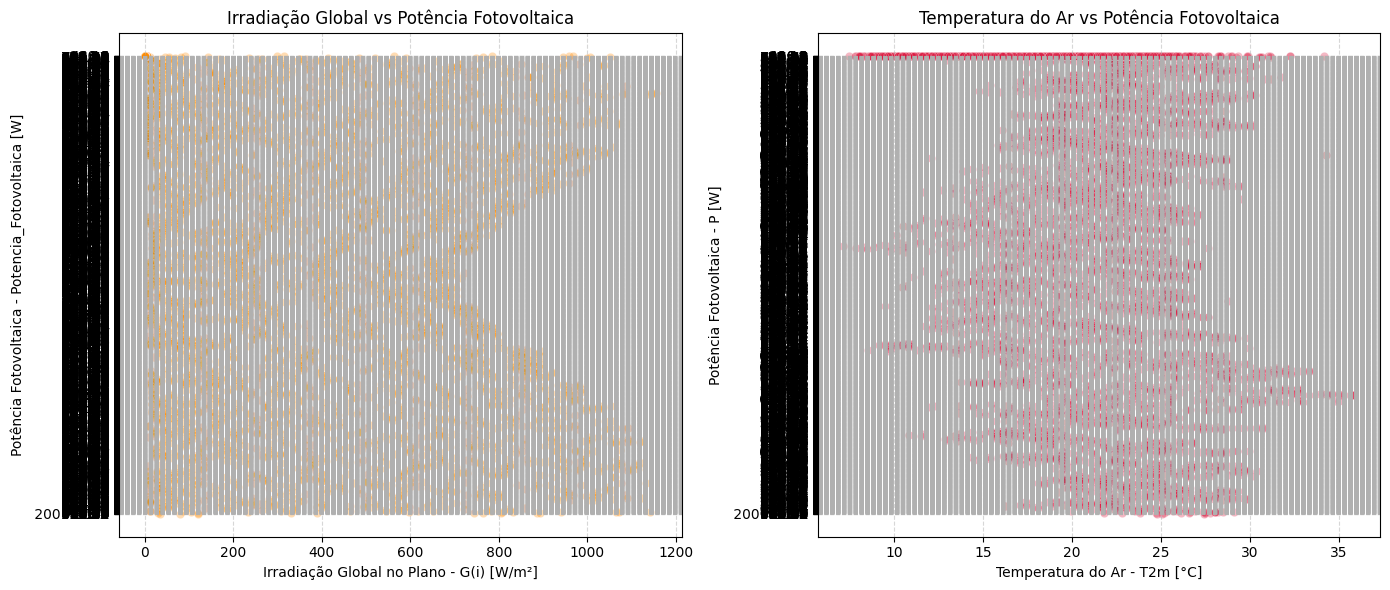

In [35]:
# 5. Visualização e Relação entre Variáveis

# Configurações visuais dos gráficos
plt.figure(figsize=(14, 6))

# 1. Gráfico de Dispersão: Irradiação Global vs Potência
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['Irradiancia_Solar'], y=df['Potencia_Fotovoltaica'], alpha=0.3, color='darkorange')
plt.title('Irradiação Global vs Potência Fotovoltaica')
plt.xlabel('Irradiação Global no Plano - G(i) [W/m²]')
plt.ylabel('Potência Fotovoltaica - Potencia_Fotovoltaica [W]')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Gráfico de Dispersão: Temperatura do Ar vs Potência
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Temperatura'], y=df['Potencia_Fotovoltaica'], alpha=0.3, color='crimson')
plt.title('Temperatura do Ar vs Potência Fotovoltaica')
plt.xlabel('Temperatura do Ar - T2m [°C]')
plt.ylabel('Potência Fotovoltaica - P [W]')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 6. Matriz de Correlação